In [5]:
!pip install catboost shap lightgbm xgboost -q

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Libraries imported successfully
Train Shape : (200000, 202)
Test Shape  : (200000, 201)

PHASE 0 : DATASET EXPLORATION
Total missing values in train : 0
Total missing values in test  : 0

Target Class Distribution:
target
0    179902
1     20098
Name: count, dtype: int64
Imbalance Ratio : 8.95 :1

Few Feature Statistics:
            mean       std      min      max
var_0  10.679914  3.040051   0.4084  20.3150
var_1  -1.627622  4.050044 -15.0434  10.3768
var_2  10.715192  2.640894   2.1171  19.3530
var_3   6.796529  2.043319  -0.0402  13.1883
var_4  11.078333  1.623150   5.0748  16.6714
var_5  -5.065317  7.863267 -32.5626  17.2516
var_6   5.408949  0.866607   2.3473   8.4477
var_7  16.545850  3.418076   5.3497  27.6918


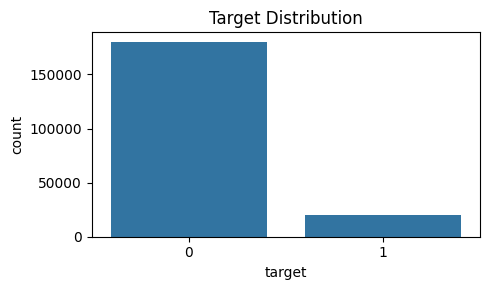

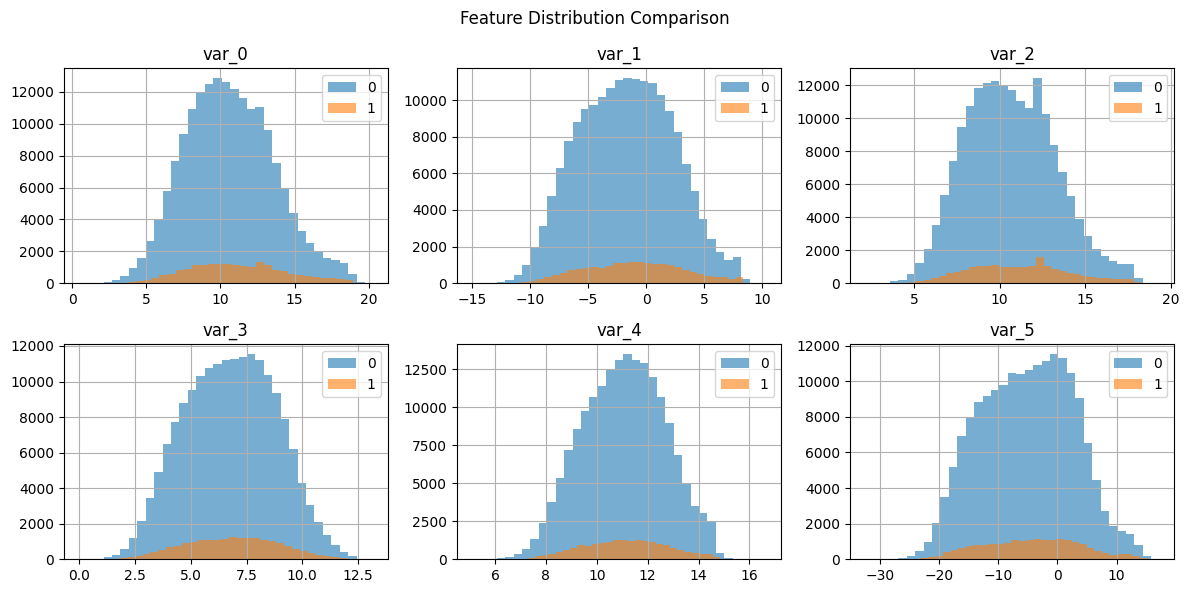


PHASE 1 : BASELINE LOGISTIC REGRESSION
Baseline ROC AUC : 0.8598618773835104

FEATURE ENGINEERING STARTED
Building count encoded features...
Building row statistical features...
Adding inverse features...
Final Feature Shape : (200000, 616)

PHASE 1 : ADVANCED MODEL DEVELOPMENT

Training LightGBM...
Fold 1 AUC : 0.8964200362886776
Fold 2 AUC : 0.8963790356884257
Fold 3 AUC : 0.8885846338070625
Fold 4 AUC : 0.8943533098819411
Fold 5 AUC : 0.8959231151081725
LightGBM OOF AUC : 0.8943352905113643

Training CatBoost...


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 1 AUC : 0.8984833505234118


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 2 AUC : 0.8994981793458366


...

Fold 3 AUC : 0.8924056551594446


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 4 AUC : 0.8974321900779592


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 5 AUC : 0.8997426430935926
CatBoost OOF AUC : 0.8975097126082175

Building final ensemble...

MODEL PERFORMANCE
Baseline Logistic AUC : 0.8598618773835104
LightGBM OOF AUC      : 0.8943352905113643
CatBoost OOF AUC      : 0.8975097126082175
Final Ensemble AUC    : 0.8976221116810007
Total Improvement     : 0.037760234297490314


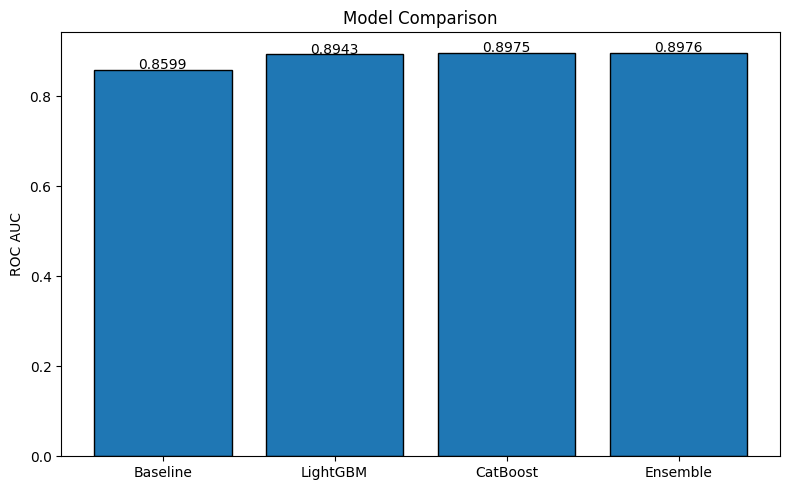


PHASE 3 : MODEL INTERPRETABILITY


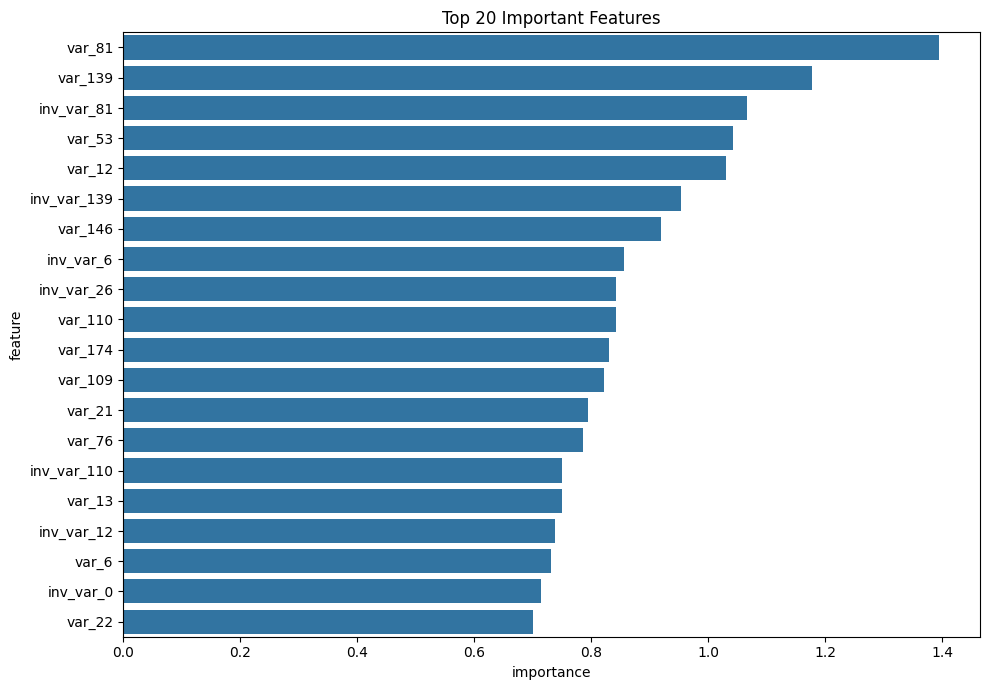

         feature  importance
81        var_81    1.395293
139      var_139    1.177643
497   inv_var_81    1.066495
53        var_53    1.042889
12        var_12    1.031095
555  inv_var_139    0.953591
146      var_146    0.919659
422    inv_var_6    0.855993
442   inv_var_26    0.842704
110      var_110    0.841743

Calculating optimized permutation importance...


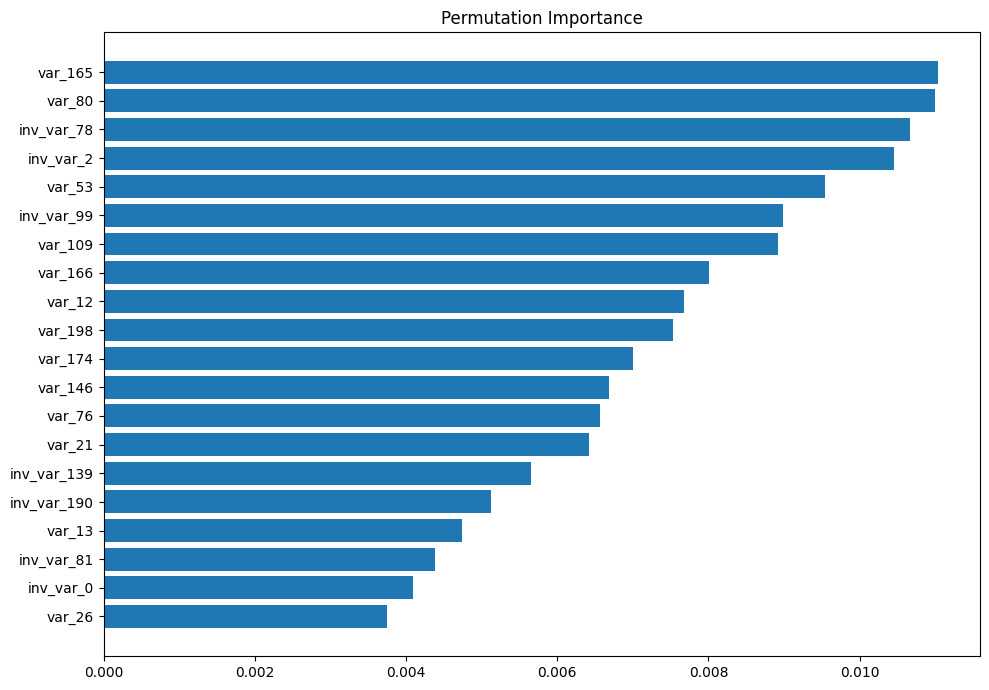


Running optimized SHAP...


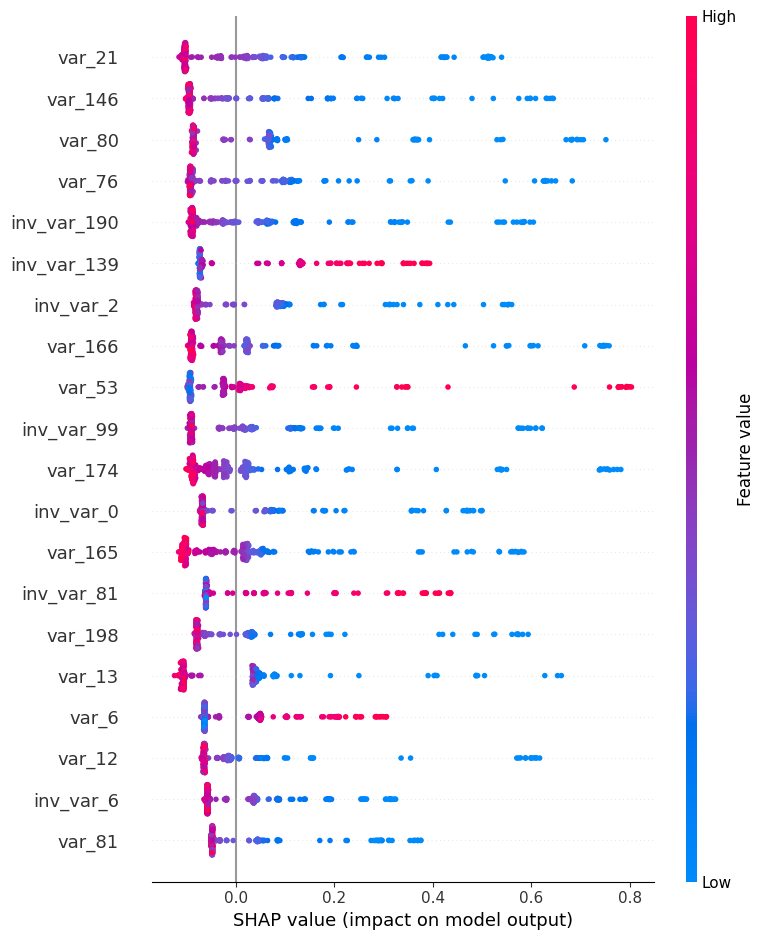

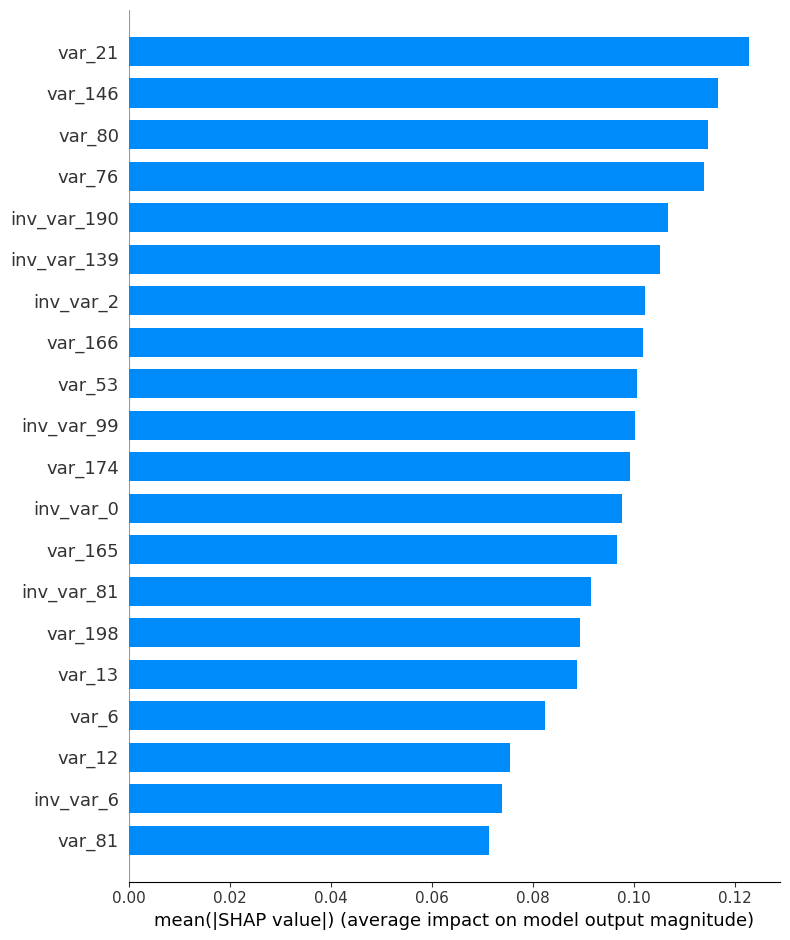

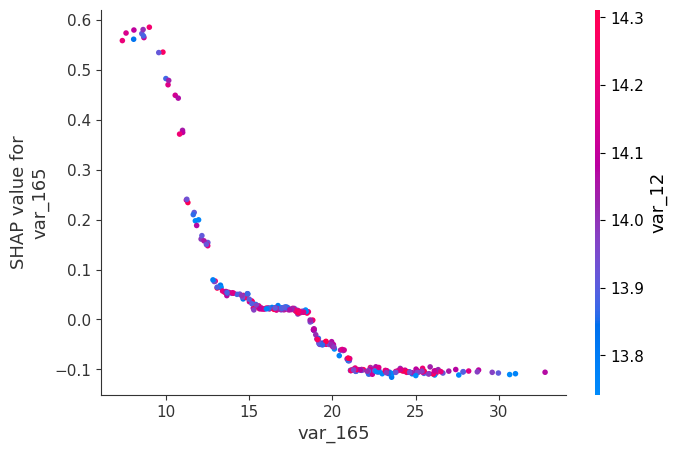


Interpretation Summary:
Count encoded rarity features dominate the prediction process.
This confirms rare and repeated feature values are strongest fraud indicators.

PHASE 2 : KAGGLE SUBMISSION
submission.csv saved successfully
  ID_code    target
0  test_0  0.070870
1  test_1  0.240604
2  test_2  0.219789
3  test_3  0.170534
4  test_4  0.038792


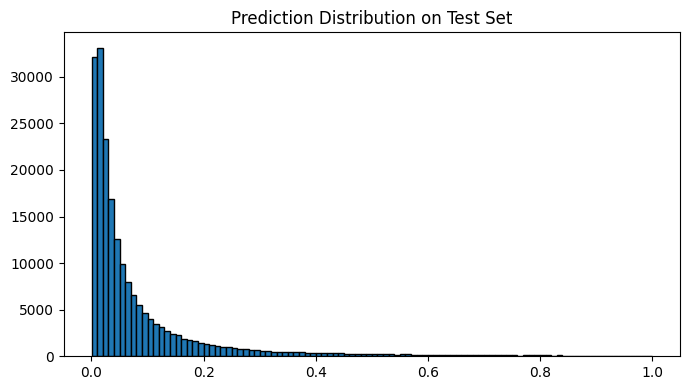


FULL PIPELINE COMPLETED SUCCESSFULLY
Final Ensemble AUC : 0.8976221116810007


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier, Pool
import shap

print('Libraries imported successfully')

# LOAD DATASET
train = pd.read_csv('/content/drive/My Drive/Colab Notebooks/train.csv')
test = pd.read_csv('/content/drive/My Drive/Colab Notebooks/test.csv')

print('Train Shape :', train.shape)
print('Test Shape  :', test.shape)

X_raw = train.drop(['ID_code', 'target'], axis=1)
y = train['target']
X_test_raw = test.drop(['ID_code'], axis=1)

# PHASE 0 : BASIC EXPLORATION

print('\nPHASE 0 : DATASET EXPLORATION')
print('Total missing values in train :', train.isnull().sum().sum())
print('Total missing values in test  :', test.isnull().sum().sum())
print('\nTarget Class Distribution:')
print(y.value_counts())
ratio = y.value_counts()[0] / y.value_counts()[1]
print('Imbalance Ratio :', round(ratio,2), ':1')
print('\nFew Feature Statistics:')
print(X_raw.describe().T[['mean','std','min','max']].head(8))

plt.figure(figsize=(5,3))
sns.countplot(x=y)
plt.title('Target Distribution')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2,3, figsize=(12,6))
for ax, col in zip(axes.flatten(), X_raw.columns[:6]):
    train[train['target']==0][col].hist(ax=ax,bins=35,alpha=0.6,label='0')
    train[train['target']==1][col].hist(ax=ax,bins=35,alpha=0.6,label='1')
    ax.set_title(col)
    ax.legend()
plt.suptitle('Feature Distribution Comparison')
plt.tight_layout()
plt.show()

# PHASE 1 : BASELINE MODEL

print('\nPHASE 1 : BASELINE LOGISTIC REGRESSION')
X_train_b, X_val_b, y_train_b, y_val_b = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_b = scaler.fit_transform(X_train_b)
X_val_b = scaler.transform(X_val_b)

baseline_model = LogisticRegression(max_iter=1000, n_jobs=-1)
baseline_model.fit(X_train_b, y_train_b)
baseline_pred = baseline_model.predict_proba(X_val_b)[:,1]
baseline_auc = roc_auc_score(y_val_b, baseline_pred)
print('Baseline ROC AUC :', baseline_auc)

# FEATURE ENGINEERING

print('\nFEATURE ENGINEERING STARTED')
X = X_raw.copy()
X_test = X_test_raw.copy()

all_data = pd.concat([X_raw, X_test_raw], axis=0).reset_index(drop=True)
all_round = (all_data*100).round()/100

print('Building count encoded features...')
for col in X_raw.columns:
    freq_map = all_round[col].value_counts()
    X['cnt_'+col] = ((X_raw[col]*100).round()/100).map(freq_map)
    X_test['cnt_'+col] = ((X_test_raw[col]*100).round()/100).map(freq_map)

print('Building row statistical features...')
for df, source in [(X,X_raw),(X_test,X_test_raw)]:
    df['row_mean'] = source.mean(axis=1)
    df['row_std'] = source.std(axis=1)
    df['row_sum'] = source.sum(axis=1)
    df['row_max'] = source.max(axis=1)
    df['row_min'] = source.min(axis=1)
    df['row_median'] = source.median(axis=1)
    df['row_range'] = source.max(axis=1)-source.min(axis=1)
    df['row_skew'] = source.skew(axis=1)
    df['pos_ratio'] = (source>0).mean(axis=1)
    df['neg_ratio'] = (source<0).mean(axis=1)
    df['abs_sum'] = np.abs(source).sum(axis=1)

cnt_cols = [c for c in X.columns if c.startswith('cnt_')]
for df in [X, X_test]:
    df['cnt_mean'] = df[cnt_cols].mean(axis=1)
    df['cnt_std'] = df[cnt_cols].std(axis=1)
    df['cnt_max'] = df[cnt_cols].max(axis=1)
    df['cnt_min'] = df[cnt_cols].min(axis=1)
    df['cnt_sum'] = df[cnt_cols].sum(axis=1)

print('Adding inverse features...')
for col in X_raw.columns:
    X['inv_'+col] = 1 - X_raw[col]
    X_test['inv_'+col] = 1 - X_test_raw[col]

print('Final Feature Shape :', X.shape)

# ADVANCED MODEL TRAINING

print('\nPHASE 1 : ADVANCED MODEL DEVELOPMENT')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lgb_params = {
    'n_estimators': 2500,
    'learning_rate': 0.03,
    'max_depth': 5,
    'num_leaves': 32,
    'subsample': 0.8,
    'colsample_bytree': 0.15,
    'objective': 'binary',
    'random_state': 42,
    'verbosity': -1
}

oof_lgb = np.zeros(len(X))
test_lgb = np.zeros(len(X_test))
lgb_scores = []

print('\nTraining LightGBM...')
for fold, (tr_idx, vl_idx) in enumerate(skf.split(X, y)):
    X_train = X.iloc[tr_idx]
    X_val = X.iloc[vl_idx]
    y_train = y.iloc[tr_idx]
    y_val = y.iloc[vl_idx]

    lgb_model = LGBMClassifier(**lgb_params)
    lgb_model.fit(X_train, y_train)

    oof_lgb[vl_idx] = lgb_model.predict_proba(X_val)[:,1]
    test_lgb += lgb_model.predict_proba(X_test)[:,1]/5

    auc = roc_auc_score(y_val, oof_lgb[vl_idx])
    lgb_scores.append(auc)
    print('Fold', fold+1, 'AUC :', auc)

lgb_auc = roc_auc_score(y, oof_lgb)
print('LightGBM OOF AUC :', lgb_auc)

cat_params = {
    'iterations': 2500,
    'learning_rate': 0.05,
    'depth': 4,
    'l2_leaf_reg': 3,
    'eval_metric': 'AUC',
    'task_type': 'GPU',
    'random_seed': 42,
    'verbose': 0
}

oof_cat = np.zeros(len(X))
test_cat = np.zeros(len(X_test))
cat_scores = []
feature_imp = []

print('\nTraining CatBoost...')
for fold, (tr_idx, vl_idx) in enumerate(skf.split(X, y)):
    X_train = X.iloc[tr_idx]
    X_val = X.iloc[vl_idx]
    y_train = y.iloc[tr_idx]
    y_val = y.iloc[vl_idx]

    cat_model = CatBoostClassifier(**cat_params)
    cat_model.fit(Pool(X_train,y_train), eval_set=Pool(X_val,y_val), early_stopping_rounds=150, use_best_model=True)

    oof_cat[vl_idx] = cat_model.predict_proba(X_val)[:,1]
    test_cat += cat_model.predict_proba(X_test)[:,1]/5

    auc = roc_auc_score(y_val, oof_cat[vl_idx])
    cat_scores.append(auc)
    feature_imp.append(cat_model.get_feature_importance())
    print('Fold', fold+1, 'AUC :', auc)

cat_auc = roc_auc_score(y, oof_cat)
print('CatBoost OOF AUC :', cat_auc)

# FINAL ENSEMBLE

print('\nBuilding final ensemble...')
total_weight = lgb_auc + cat_auc
oof_final = (lgb_auc*oof_lgb + cat_auc*oof_cat)/total_weight
test_final = (lgb_auc*test_lgb + cat_auc*test_cat)/total_weight
final_auc = roc_auc_score(y, oof_final)

print('\nMODEL PERFORMANCE')
print('Baseline Logistic AUC :', baseline_auc)
print('LightGBM OOF AUC      :', lgb_auc)
print('CatBoost OOF AUC      :', cat_auc)
print('Final Ensemble AUC    :', final_auc)
print('Total Improvement     :', final_auc-baseline_auc)

# VISUALIZATION

model_names = ['Baseline','LightGBM','CatBoost','Ensemble']
model_scores = [baseline_auc,lgb_auc,cat_auc,final_auc]
plt.figure(figsize=(8,5))
bars = plt.bar(model_names, model_scores, edgecolor='black')
for bar, val in zip(bars, model_scores):
    plt.text(bar.get_x()+bar.get_width()/2, val+0.001, round(val,4), ha='center')
plt.ylabel('ROC AUC')
plt.title('Model Comparison')
plt.tight_layout()
plt.show()

# PHASE 3 : MODEL INTERPRETABILITY

print('\nPHASE 3 : MODEL INTERPRETABILITY')
fi_mean = np.mean(feature_imp, axis=0)
fi_df = pd.DataFrame({'feature':X.columns,'importance':fi_mean}).sort_values('importance',ascending=False)

plt.figure(figsize=(10,7))
sns.barplot(x='importance', y='feature', data=fi_df.head(20))
plt.title('Top 20 Important Features')
plt.tight_layout()
plt.show()

print(fi_df.head(10))

# FAST PERMUTATION IMPORTANCE
print('\nCalculating optimized permutation importance...')
top30_features = fi_df.head(30)['feature'].tolist()
X_small = X[top30_features]

_, X_perm, _, y_perm = train_test_split(X_small, y, test_size=0.03, stratify=y, random_state=42)

perm_cat = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=4,
    task_type='GPU',
    verbose=0,
    random_seed=42
)
perm_cat.fit(X_small, y)

perm = permutation_importance(
    perm_cat,
    X_perm,
    y_perm,
    scoring='roc_auc',
    n_repeats=2,
    random_state=42,
    n_jobs=1
)

perm_df = pd.DataFrame({'feature':top30_features,'perm_score':perm.importances_mean}).sort_values('perm_score',ascending=False)

plt.figure(figsize=(10,7))
plt.barh(perm_df.head(20)['feature'][::-1], perm_df.head(20)['perm_score'][::-1])
plt.title('Permutation Importance')
plt.tight_layout()
plt.show()

# FAST SHAP
print('\nRunning optimized SHAP...')
shap_sample = X_small.sample(300, random_state=42)
explainer = shap.TreeExplainer(perm_cat)
shap_values = explainer.shap_values(shap_sample)
shap.summary_plot(shap_values, shap_sample, max_display=20)
shap.summary_plot(shap_values, shap_sample, plot_type='bar', max_display=20)

top_feature = perm_df['feature'].iloc[0]
shap.dependence_plot(top_feature, shap_values, shap_sample)

print('\nInterpretation Summary:')
print('Count encoded rarity features dominate the prediction process.')
print('This confirms rare and repeated feature values are strongest fraud indicators.')

# PHASE 2 : SUBMISSION

print('\nPHASE 2 : KAGGLE SUBMISSION')
submission = pd.DataFrame({'ID_code':test['ID_code'], 'target':test_final})
submission.to_csv('submission.csv', index=False)
print('submission.csv saved successfully')
print(submission.head())

plt.figure(figsize=(7,4))
plt.hist(test_final, bins=100, edgecolor='black')
plt.title('Prediction Distribution on Test Set')
plt.tight_layout()
plt.show()

print('\nFULL PIPELINE COMPLETED SUCCESSFULLY')
print('Final Ensemble AUC :', final_auc)

In [10]:
import pandas as pd

submission = pd.read_csv('/content/submission.csv')

# show all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print(submission)

Output hidden; open in https://colab.research.google.com to view.

In [11]:
from google.colab import files
files.download('/content/submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>